# 03 — Review Clustering / Truth Discovery

K-Means detects behavioral patterns, not proof of fake reviews. Cluster meaning is assigned only after human review.

In [1]:
from pathlib import Path
import hashlib
import json
import warnings
import numpy as np
import pandas as pd
import yaml

warnings.filterwarnings("ignore")
current = Path.cwd().resolve()
PROJECT_ROOT = next((p for p in (current, *current.parents) if (p / "config" / "config.yaml").exists()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Cannot locate project root containing config/config.yaml")
with (PROJECT_ROOT / "config" / "config.yaml").open(encoding="utf-8") as handle:
    CONFIG = yaml.safe_load(handle)

def project_path(key):
    return PROJECT_ROOT / CONFIG["paths"][key]

OUTPUT = project_path("output")
PROCESSED = project_path("processed")
for folder in [OUTPUT / "reports", OUTPUT / "figures", OUTPUT / "models", OUTPUT / "labeling", OUTPUT / "logs", OUTPUT / "powerbi", PROCESSED]:
    folder.mkdir(parents=True, exist_ok=True)
fingerprint_paths = [PROJECT_ROOT / "config" / "config.yaml", project_path("shops")]
for key in ("products", "reviews"):
    fingerprint_paths.extend(sorted(project_path(key).glob("shop_*.json")))
seller_candidate = project_path("seller_metrics")
for candidate in (seller_candidate, seller_candidate.with_suffix(".xlsx")):
    if candidate.exists(): fingerprint_paths.append(candidate)
digest = hashlib.sha256()
for path in fingerprint_paths:
    digest.update(str(path.relative_to(PROJECT_ROOT)).encode("utf-8")); digest.update(path.read_bytes())
INPUT_FINGERPRINT = digest.hexdigest()
print("PROJECT_ROOT:", PROJECT_ROOT)
print("INPUT_FINGERPRINT:", INPUT_FINGERPRINT)

PROJECT_ROOT: /app/workspace/shopee_dikw
INPUT_FINGERPRINT: ffd74b13d032b8f45851e7c2ee986aa9a766cc1f44f58755688039a237e54cd8


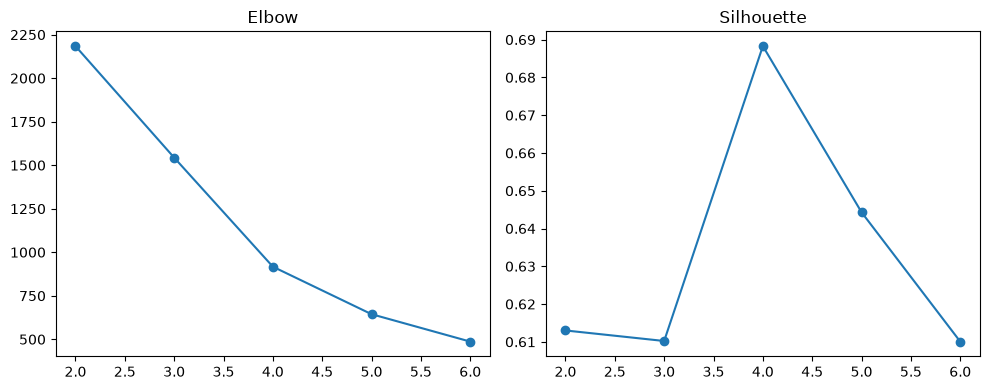

{'mode': 'FULL', 'active_features': ['Comment_Length', 'rating', 'Sentiment_Score', 'has_image'], 'selected_k': 3}


['/app/workspace/shopee_dikw/output/models/kmeans_reviews.joblib']

In [2]:
import os
os.environ.setdefault("MPLCONFIGDIR", str(OUTPUT / ".matplotlib"))
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "1")
import joblib, matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

reviews = pd.read_csv(PROCESSED / "reviews_clean.csv")
features = CONFIG["clustering"]["features"]
numeric_features = reviews[features].apply(pd.to_numeric, errors="coerce")
feature_coverage = pd.DataFrame({
    "Feature": features,
    "Observed_Count": [numeric_features[c].notna().sum() for c in features],
    "Observed_Rate": [numeric_features[c].notna().mean() for c in features],
    "Unique_Observed_Values": [numeric_features[c].nunique(dropna=True) for c in features],
})
feature_coverage["Usable"] = (feature_coverage["Observed_Count"] >= 3) & (feature_coverage["Unique_Observed_Values"] >= 2)
feature_coverage.to_csv(OUTPUT / "reports" / "cluster_feature_coverage.csv", index=False)
active_features = feature_coverage.loc[feature_coverage["Usable"], "Feature"].tolist()
missing_required = [c for c in features if c not in active_features]
if missing_required:
    print("EXPLORATORY FALLBACK: unavailable/non-varying required features were excluded:", missing_required)
    print("This run is not submission-ready until all four required features are observed.")
if not active_features:
    raise ValueError("No observed clustering feature has enough coverage and variation")
complete = numeric_features[active_features].notna().all(axis=1)
if (~complete).any(): print(f"Excluded {(~complete).sum()} reviews with missing active features; values were not imputed.")
reviews = reviews.loc[complete].copy()
X = numeric_features.loc[complete, active_features]
if len(X) < 3: raise ValueError("Insufficient reviews for exploratory clustering")
distinct_rows = len(X.drop_duplicates())
if distinct_rows < 2: raise ValueError("Observed clustering features contain fewer than two distinct patterns")
scaled = StandardScaler().fit_transform(X)
rows = []
for k in CONFIG["clustering"]["k_candidates"]:
    if 2 <= k < len(X) and k <= distinct_rows:
        model = KMeans(n_clusters=k, random_state=CONFIG["project"]["random_state"], n_init=20).fit(scaled)
        rows.append({"k":k,"inertia":model.inertia_,"silhouette":silhouette_score(scaled,model.labels_)})
evaluation = pd.DataFrame(rows)
evaluation.to_csv(OUTPUT / "reports" / "cluster_k_evaluation.csv", index=False)
fig, axes = plt.subplots(1,2,figsize=(10,4)); axes[0].plot(evaluation["k"],evaluation["inertia"],marker="o"); axes[0].set_title("Elbow"); axes[1].plot(evaluation["k"],evaluation["silhouette"],marker="o"); axes[1].set_title("Silhouette"); fig.tight_layout(); fig.savefig(OUTPUT / "figures" / "cluster_selection.png",dpi=160); plt.show(); plt.close(fig)

selected_k = min(CONFIG["clustering"]["n_clusters"], distinct_rows, len(X)-1)
selected_k = max(2, selected_k)
print({"mode":"FULL" if not missing_required else "EXPLORATORY_PARTIAL_FEATURES", "active_features":active_features, "selected_k":selected_k})
pipeline = Pipeline([("scaler",StandardScaler()),("model",KMeans(n_clusters=selected_k,random_state=CONFIG["project"]["random_state"],n_init=20))])
reviews["Cluster_Label"] = pipeline.fit_predict(X)
joblib.dump(pipeline, OUTPUT / "models" / "kmeans_reviews.joblib")

In [3]:
profile = reviews.groupby("Cluster_Label").agg(Review_Count=("review_id","count"),Avg_Comment_Length=("Comment_Length","mean"),Avg_Rating=("rating","mean"),Image_Rate=("has_image","mean"),Avg_Sentiment_Score=("Sentiment_Score","mean"),Suspicious_Username_Rate=("Suspicious_Username","mean")).reset_index()
samples = reviews.sort_values(["Cluster_Label","Comment_Length"]).groupby("Cluster_Label",group_keys=False).head(5)[["Cluster_Label","Shop_ID","review_id","review_text","rating","has_image"]]
reviews.to_csv(PROCESSED / "reviews_clustered.csv", index=False)
profile.to_csv(OUTPUT / "reports" / "cluster_profile.csv", index=False)
samples.to_csv(OUTPUT / "reports" / "cluster_review_samples.csv", index=False)
display(profile); display(samples)

mapping = {int(k):float(v) for k,v in CONFIG["clustering"].get("authenticity_mapping",{}).items()}
if set(mapping) != set(reviews["Cluster_Label"].unique()):
    print("BLOCKED: team must map every cluster to 0.0, 0.5, or 1.0 in config.yaml after reviewing profiles and samples.")
else:
    if not set(mapping.values()) <= {0.0,0.5,1.0}: raise ValueError("Authenticity mapping values must be 0, 0.5 or 1")
    reviews["Is_Authentic"] = reviews["Cluster_Label"].map(mapping)
    report = reviews.groupby("Shop_ID").agg(Total_Reviews=("review_id","count"),Authentic_Review_Rate=("Is_Authentic","mean"),Suspicious_Review_Rate=("Is_Authentic",lambda s:(s==0).mean())).reset_index()
    reviews.to_csv(PROCESSED / "reviews_clustered.csv", index=False)
    report.to_csv(OUTPUT / "reports" / "Shop_Authenticity_Report.csv", index=False)
    auth_metadata = {"input_fingerprint":INPUT_FINGERPRINT,"authenticity_mapping":{str(k):float(v) for k,v in mapping.items()},"cluster_count":int(reviews["Cluster_Label"].nunique())}
    (OUTPUT / "reports" / "authenticity_metadata.json").write_text(json.dumps(auth_metadata,ensure_ascii=False,indent=2),encoding="utf-8")
    display(report)

,Cluster_Label,Review_Count,Avg_Comment_Length,Avg_Rating,Image_Rate,Avg_Sentiment_Score,Suspicious_Username_Rate
0,0,643,167.396579,4.99689,1.0,0.850337,0.127527
1,1,84,150.154762,5.00000,0.0,0.879365,0.059524
2,2,4,262.750000,2.75000,0.5,0.300000,0.000000


,Cluster_Label,Shop_ID,review_id,review_text,rating,has_image
2,0,01_001,85592334475,Vừa chân ạ,5,1
17,0,01_001,48395364412,Đúng với mô tả,5,1
222,0,01_005,44442252453,Sản phẩm quá ok nha,5,1
14,0,01_001,98951860343,đáng để mua nhé mng ơi,5,1
165,0,01_004,108317783148,Rất hài lòng khi nhận hàng,5,1
330,1,01_007,76342666346,Ngon trong tầm giá,5,0
15,1,01_001,61891464890,"giày đẹp chính hãng, giá tốt",5,0
30,1,01_001,110263921056,"Giống mô tả, mang thoải nái mặc dù hơi rộng nhẹ",5,0
16,1,01_001,52862960235,Giá sale tốt. Giày hơi rộng chút. Ship hàng kh...,5,0
540,1,01_012,15033893386,"hạt dẻ rồi. Shop đóng gói kỹ, giao nhanh, sẽ ủ...",5,0


,Shop_ID,Total_Reviews,Authentic_Review_Rate,Suspicious_Review_Rate
0,01_001,31,0.967742,0.0
1,01_002,50,1.000000,0.0
2,01_003,50,1.000000,0.0
3,01_004,50,1.000000,0.0
4,01_005,50,1.000000,0.0
5,01_006,50,1.000000,0.0
6,01_007,50,1.000000,0.0
7,01_008,50,1.000000,0.0
8,01_009,50,0.990000,0.0
9,01_010,50,1.000000,0.0
